# Model Comparison. Weekly 5-Bucket Strategy
Compares Random Forest, XGBoost, LightGBM, and Gradient Boosting
on the same pipeline, same train/test split, same top-30 features.

In [ ]:
from __future__ import annotations
from pathlib import Path
import warnings, pickle, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
warnings.filterwarnings('ignore')

BASE_DIR = Path.cwd().parent

IN_FILE = BASE_DIR / 'Data/data_for_experiments.csv'
OUT_DIR = BASE_DIR / 'Figures'

TRAIN_CUTOFF = '2024-01'
FORWARD_DAYS = 7
MIN_COINS    = 20
TOP_N        = 30

LABEL_ORDER = ['Strong Avoid', 'Avoid', 'Neutral', 'Buy', 'Strong Buy']
LABEL_MAP   = {'Strong Avoid': 0, 'Avoid': 1, 'Neutral': 2, 'Buy': 3, 'Strong Buy': 4}
BINS        = [0, 0.10, 0.30, 0.70, 0.90, 1.001]
LONG_LABEL  = 'Strong Buy'
SHORT_LABEL = 'Strong Avoid'

COLORS = {
    'Strong Buy':   '#1D9E75',
    'Buy':          '#97C459',
    'Neutral':      '#888780',
    'Avoid':        '#F0997B',
    'Strong Avoid': '#E24B4A',
}

LEAKY_COLS = {
    'label', 'forward_return_7d', 'forward_sharpe_7d', 'forward_sharpe_rank',
    'return_1d_rank', 'return_1d_zscore', 'return_7d_rank', 'return_7d_zscore',
    'return_30d_rank', 'return_30d_zscore', 'volatility_30d_rank', 'volatility_30d_zscore',
    'rsi_14_rank', 'rsi_14_zscore', 'macd_hist_rank', 'macd_hist_zscore',
    'bb_pct_rank', 'bb_pct_zscore', 'atr_pct_rank', 'atr_pct_zscore',
    'obv_divergence_rank', 'obv_divergence_zscore', 'stoch_k_rank', 'stoch_k_zscore',
    'adx_rank', 'adx_zscore', 'volume_vs_30d_avg_rank', 'volume_vs_30d_avg_zscore',
    'drawdown_from_90d_peak_rank', 'drawdown_from_90d_peak_zscore',
    'price_vs_ath_rank', 'price_vs_ath_zscore', 'range_position_30d_rank',
    'range_position_30d_zscore', 'consecutive_up_days_rank', 'consecutive_up_days_zscore',
    'consecutive_down_days_rank', 'consecutive_down_days_zscore',
    'coin_age_days_rank', 'coin_age_days_zscore',
    'momentum_score', 'mean_reversion_score', 'trend_score',
    'asset_id', 'year_week', 'date', 'timestamp', 'exchange',
    'pair_symbol', 'source', 'open', 'high', 'low', 'close',
    'granularity', 'is_active',
}

CS_FEATURES = [
    'return_1d', 'return_7d', 'return_30d', 'volatility_30d',
    'rsi_14', 'macd_hist', 'bb_pct', 'atr_pct', 'obv_divergence',
    'stoch_k', 'adx', 'volume_vs_30d_avg', 'drawdown_from_90d_peak',
    'price_vs_ath', 'range_position_30d', 'consecutive_up_days',
    'consecutive_down_days', 'coin_age_days', 'galaxy_score', 'alt_rank',
    'market_cap_usd', 'coin_mcap_share_recalc', 'oi_usd', 'funding_rate',
    'taker_buy_ratio',
]

print('Config loaded.')

Config loaded.


## 1. Load data and build weekly labels

In [ ]:
df = pd.read_csv(IN_FILE, low_memory=False)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['asset_id', 'date']).reset_index(drop=True)
df['year_week'] = df['date'].dt.strftime('%G-W%V')

print(f'Loaded: {df.shape[0]:,} rows x {df.shape[1]} cols')
print(f'Coins : {df["asset_id"].nunique()}')
print(f'Range : {df["date"].min().date()} -> {df["date"].max().date()}')

def compute_forward_sharpe_7d(group):
    closes  = group['close'].values
    results = []
    for i in range(len(closes)):
        end = i + FORWARD_DAYS
        if end >= len(closes):
            results.append(np.nan)
            continue
        window     = closes[i:end]
        daily_rets = np.diff(window) / window[:-1]
        fwd_ret    = (window[-1] - window[0]) / window[0]
        vol        = daily_rets.std() * np.sqrt(365)
        results.append((fwd_ret / vol) if vol > 1e-8 else 0.0)
    return pd.Series(results, index=group.index)

print('Computing forward Sharpe (7d)...')
df['forward_sharpe_7d'] = (
    df.groupby('asset_id', group_keys=False)
    .apply(compute_forward_sharpe_7d)
)
df['forward_return_7d'] = (
    df.groupby('asset_id')['close']
    .transform(lambda x: x.shift(-FORWARD_DAYS) / x - 1)
)

weekly = (
    df.dropna(subset=['forward_sharpe_7d'])
    .sort_values('date')
    .groupby(['asset_id', 'year_week'])
    .last()
    .reset_index()
)

def assign_labels(group):
    if len(group) < MIN_COINS:
        return group.assign(label=np.nan, forward_sharpe_rank=np.nan)
    q = group['forward_sharpe_7d'].rank(pct=True)
    group = group.copy()
    group['forward_sharpe_rank'] = q
    group['label'] = pd.cut(q, bins=BINS, labels=LABEL_ORDER, include_lowest=True)
    return group

weekly = (
    weekly.groupby('year_week', group_keys=False)
    .apply(assign_labels)
    .dropna(subset=['label'])
    .reset_index(drop=True)
)

print(f'Weekly snapshots: {len(weekly):,} rows, {weekly["year_week"].nunique()} weeks')
print('Label distribution:')
print(weekly['label'].value_counts()[LABEL_ORDER].to_string())

Loaded: 211,498 rows x 99 cols
Coins : 164
Range : 2019-03-04 -> 2026-03-01
Computing forward Sharpe (7d)...
Weekly snapshots: 30,050 rows, 361 weeks
Label distribution:
label
Strong Avoid     2878
Avoid            5979
Neutral         12005
Buy              5980
Strong Buy       3208


## 2. Cross-sectional features and train/test split

In [ ]:
cs_cols = [c for c in CS_FEATURES if c in weekly.columns]
for col in cs_cols:
    weekly[f'{col}_rank']   = weekly.groupby('year_week')[col].transform(lambda x: x.rank(pct=True))
    weekly[f'{col}_zscore'] = weekly.groupby('year_week')[col].transform(
        lambda x: (x - x.mean()) / (x.std() if x.std() > 0 else 1)
    )
print(f'Cross-sectional features built: {len(cs_cols)*2} new columns')

cutoff_date = pd.Timestamp(TRAIN_CUTOFF + '-01')
train_df = weekly[pd.to_datetime(weekly['date']) <  cutoff_date].copy()
test_df  = weekly[pd.to_datetime(weekly['date']) >= cutoff_date].copy()
print(f'Train: {len(train_df):,} rows ({train_df["year_week"].min()} -> {train_df["year_week"].max()})')
print(f'Test : {len(test_df):,} rows ({test_df["year_week"].min()} -> {test_df["year_week"].max()})')

all_features = [
    c for c in weekly.columns
    if c not in LEAKY_COLS
    and weekly[c].dtype in [np.float64, np.float32, np.int64, np.int32]
]
null_rates   = train_df[all_features].isnull().mean()
all_features = [f for f in all_features if null_rates[f] <= 0.30]
print(f'Candidate features (null < 30%): {len(all_features)}')

def prep(d, cols):
    return d[cols].fillna(0).replace([np.inf, -np.inf], 0).clip(-1e9, 1e9)

y_train = train_df['label'].map(LABEL_MAP)
y_test  = test_df['label'].map(LABEL_MAP)

Cross-sectional features built: 50 new columns
Train: 15,651 rows (2019-W13 -> 2023-W52)
Test : 14,399 rows (2024-W01 -> 2026-W08)
Candidate features (null < 30%): 103


## 3. Two-pass feature selection using Random Forest
RF Pass 1 selects the top-30 features. All models then train on the same top-30.

In [ ]:
print(f'Pass 1: selecting top {TOP_N} features from {len(all_features)} candidates...')
rf_selector = RandomForestClassifier(
    n_estimators=200, max_depth=10, min_samples_leaf=5,
    max_features='sqrt', class_weight='balanced',
    oob_score=True, n_jobs=-1, random_state=42
)
rf_selector.fit(prep(train_df, all_features), y_train)
imp1  = pd.Series(rf_selector.feature_importances_, index=all_features).sort_values(ascending=False)
top30 = imp1.head(TOP_N).index.tolist()

print(f'Pass 1 OOB: {rf_selector.oob_score_*100:.2f}%')
print(f'Top {TOP_N} features selected:')
for i, (feat, imp) in enumerate(imp1.head(TOP_N).items(), 1):
    print(f'  {i:>2}. {feat:<45} {imp:.5f}')

FEAT_FILE.write_text('\n'.join(top30))
print(f'\nFeature list saved -> {FEAT_FILE.name}')

Pass 1: selecting top 30 features from 103 candidates...
Pass 1 OOB: 28.85%
Top 30 features selected:
   1. atr_pct                                       0.02186
   2. coin_age_days                                 0.02091
   3. price_vs_atl                                  0.01966
   4. price_vs_ath                                  0.01953
   5. volatility_30d                                0.01936
   6. return_1d                                     0.01916
   7. atr_14                                        0.01867
   8. bb_width                                      0.01772
   9. rsi_14                                        0.01697
  10. return_7d                                     0.01661
  11. volume_vs_30d_avg                             0.01641
  12. obv_divergence                                0.01640
  13. price_vs_ema50                                0.01630
  14. macd_hist                                     0.01608
  15. stoch_d                                       0.0151

## 4. Train all four models on top-30 features

In [9]:
MODELS = {
    'Random Forest': RandomForestClassifier(
        n_estimators=500, max_depth=12, min_samples_leaf=5,
        max_features='sqrt', class_weight='balanced',
        oob_score=True, n_jobs=-1, random_state=42
    ),
    'XGBoost': XGBClassifier(
        n_estimators=500, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='mlogloss', verbosity=0,
        random_state=42, n_jobs=-1
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=500, max_depth=6, learning_rate=0.05,
        class_weight='balanced', random_state=42,
        n_jobs=-1, verbose=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        random_state=42
    ),
}

X_train = prep(train_df, top30)
X_test  = prep(test_df,  top30)

trained_models = {}
predictions    = {}

for name, clf in MODELS.items():
    print(f'Training {name}...', end=' ', flush=True)
    t0 = time.time()
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    elapsed = time.time() - t0
    acc = accuracy_score(y_test, y_pred)
    print(f'done in {elapsed:.1f}s  |  test acc: {acc*100:.2f}%')
    trained_models[name] = clf
    predictions[name]    = y_pred

print('\nAll models trained.')

Training Random Forest... done in 4.9s  |  test acc: 34.49%
Training XGBoost... done in 4.8s  |  test acc: 38.17%
Training LightGBM... done in 6.5s  |  test acc: 29.14%
Training Gradient Boosting... done in 287.1s  |  test acc: 36.39%

All models trained.


## 5. Classification metrics comparison

In [10]:
baseline = 1 / len(LABEL_ORDER)
rows = []

for name, y_pred in predictions.items():
    acc   = accuracy_score(y_test, y_pred)
    macro = f1_score(y_test, y_pred, average='macro')
    rows.append({'Model': name, 'Accuracy': acc, 'Macro F1': macro, 'Lift (pp)': (acc - baseline)*100})
    print(f'\n{name}')
    print(f'  Accuracy : {acc*100:.2f}%  (vs {baseline*100:.0f}% baseline, lift +{(acc-baseline)*100:.2f}pp)')
    print(f'  Macro F1 : {macro*100:.2f}%')
    print(classification_report(y_test, y_pred, target_names=LABEL_ORDER))

clf_df = pd.DataFrame(rows)
print('\n=== Classification Summary ===')
print(clf_df.to_string(index=False))


Random Forest
  Accuracy : 34.49%  (vs 20% baseline, lift +14.49pp)
  Macro F1 : 24.66%
              precision    recall  f1-score   support

Strong Avoid       0.19      0.25      0.21      1397
       Avoid       0.24      0.12      0.16      2871
     Neutral       0.44      0.63      0.52      5756
         Buy       0.22      0.14      0.17      2871
  Strong Buy       0.21      0.13      0.16      1504

    accuracy                           0.34     14399
   macro avg       0.26      0.26      0.25     14399
weighted avg       0.31      0.34      0.31     14399


XGBoost
  Accuracy : 38.17%  (vs 20% baseline, lift +18.17pp)
  Macro F1 : 18.84%
              precision    recall  f1-score   support

Strong Avoid       0.23      0.08      0.12      1397
       Avoid       0.21      0.06      0.09      2871
     Neutral       0.42      0.86      0.56      5756
         Buy       0.20      0.07      0.10      2871
  Strong Buy       0.29      0.04      0.07      1504

    accuracy 

## 6. Bucket return analysis per model

In [11]:
def bucket_stats(y_pred_labels, test_df):
    rows = []
    for label in LABEL_ORDER:
        b = test_df[y_pred_labels == label]['forward_return_7d']
        rows.append({
            'label':   label,
            'n':       len(b),
            'avg':     b.mean()   * 100,
            'median':  b.median() * 100,
            'std':     b.std()    * 100,
            'pct_pos': (b > 0).mean() * 100,
        })
    return pd.DataFrame(rows)

def strategy_stats(y_pred_labels, test_df):
    weeks = sorted(test_df['year_week'].unique())
    spreads = []
    for wk in weeks:
        m    = test_df[test_df['year_week'] == wk]
        mask = y_pred_labels[m.index]
        long  = m[mask == LONG_LABEL]['forward_return_7d'].median()
        short = m[mask == SHORT_LABEL]['forward_return_7d'].median()
        if pd.notna(long) and pd.notna(short):
            spreads.append(long - short)
    spreads = pd.Series(spreads)
    return {
        'avg_spread':  spreads.mean()  * 100,
        'win_rate':    (spreads > 0).mean() * 100,
        'ann_spread':  spreads.mean()  * 52 * 100,
        'n_weeks':     len(spreads),
    }

all_results = []

for name, y_pred in predictions.items():
    y_pred_labels = pd.Series(
        [LABEL_ORDER[p] for p in y_pred],
        index=test_df.index
    )
    bdf   = bucket_stats(y_pred_labels, test_df)
    stats = strategy_stats(y_pred_labels, test_df)

    acc   = accuracy_score(y_test, predictions[name])
    macro = f1_score(y_test, predictions[name], average='macro')

    all_results.append({
        'Model':          name,
        'Accuracy (%)':   round(acc   * 100, 2),
        'Macro F1 (%)':   round(macro * 100, 2),
        'Lift (pp)':      round((acc - baseline) * 100, 2),
        'Avg Spread (%)': round(stats['avg_spread'], 2),
        'Win Rate (%)':   round(stats['win_rate'],   1),
        'Ann. Spread (%)':round(stats['ann_spread'], 1),
    })

    print(f'\n=== {name} ===')
    print(bdf.round(2).to_string(index=False))
    print(f"  Avg weekly spread : {stats['avg_spread']:+.2f}%")
    print(f"  Win rate          : {stats['win_rate']:.0f}%")
    print(f"  Ann. spread (x52) : {stats['ann_spread']:+.1f}%")

results_df = pd.DataFrame(all_results)
results_df.to_csv(RESULTS_FILE, index=False)

print('\n' + '='*65)
print('FINAL COMPARISON TABLE')
print('='*65)
print(results_df.to_string(index=False))
print(f'\nResults saved -> {RESULTS_FILE.name}')


=== Random Forest ===
       label    n   avg  median   std  pct_pos
Strong Avoid 1878 -0.45   -0.08 18.64    41.00
       Avoid 1468 -0.32   -3.34 17.60    41.08
     Neutral 8266 -0.34   -1.44 13.66    43.70
         Buy 1849  1.00   -0.83 16.28    46.78
  Strong Buy  938  3.14    0.01 20.35    51.07
  Avg weekly spread : +2.45%
  Win rate          : 67%
  Ann. spread (x52) : +127.3%

=== XGBoost ===
       label     n   avg  median   std  pct_pos
Strong Avoid   497 -1.45   -0.05 16.46    38.03
       Avoid   769 -1.53   -2.18 16.24    40.31
     Neutral 11926  0.06   -1.37 15.51    43.77
         Buy  1005  0.85    0.00 14.80    49.95
  Strong Buy   202  5.08    0.02 22.74    53.47
  Avg weekly spread : +6.42%
  Win rate          : 72%
  Ann. spread (x52) : +333.9%

=== LightGBM ===
       label    n   avg  median   std  pct_pos
Strong Avoid 1476 -1.43   -0.14 15.97    40.58
       Avoid 2797  0.14   -1.82 17.94    41.94
     Neutral 5897 -0.26   -1.58 14.71    43.26
         Buy 2

## 7. Figure 1 — Classification accuracy comparison

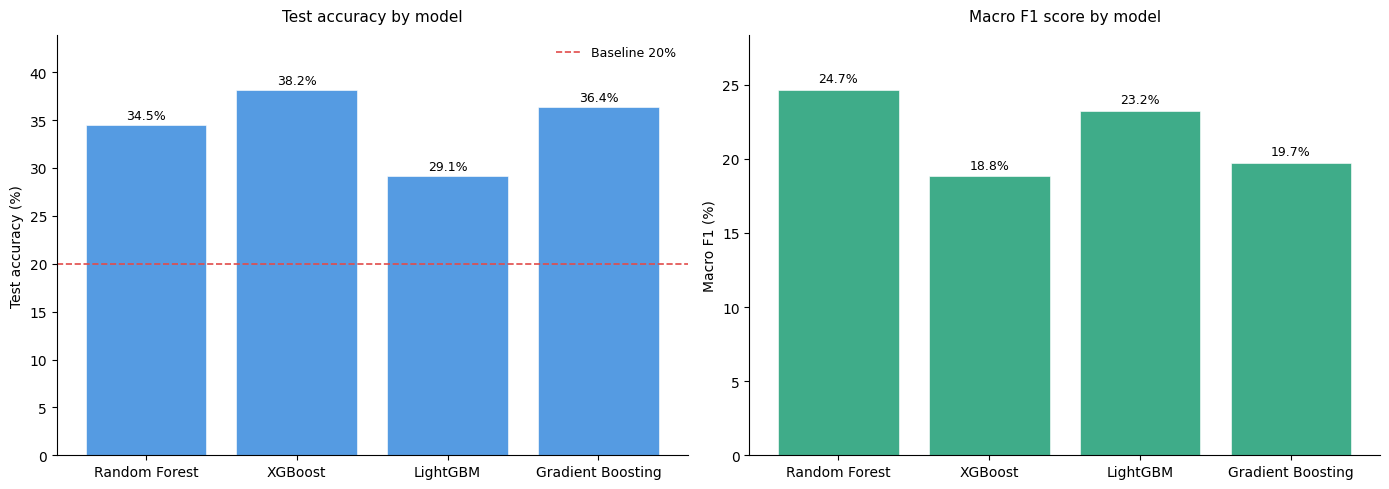

Saved -> fig1_classification_comparison.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('white')
model_names = results_df['Model'].tolist()
bar_color   = '#378ADD'
x = range(len(model_names))

ax = axes[0]
bars = ax.bar(x, results_df['Accuracy (%)'], color=bar_color, alpha=0.85,
              edgecolor='white', linewidth=0.5)
ax.axhline(baseline * 100, color='#E24B4A', lw=1.2, ls='--', label=f'Baseline {baseline*100:.0f}%')
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=10)
ax.set_ylabel('Test accuracy (%)', fontsize=10)
ax.set_title('Test accuracy by model', fontsize=11, fontweight='500', pad=10)
ax.set_ylim(0, max(results_df['Accuracy (%)']) * 1.15)
ax.legend(fontsize=9, framealpha=0)
ax.spines[['top', 'right']].set_visible(False)
ax.set_facecolor('white')
for bar, val in zip(bars, results_df['Accuracy (%)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

ax = axes[1]
bars = ax.bar(x, results_df['Macro F1 (%)'], color='#1D9E75', alpha=0.85,
              edgecolor='white', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=10)
ax.set_ylabel('Macro F1 (%)', fontsize=10)
ax.set_title('Macro F1 score by model', fontsize=11, fontweight='500', pad=10)
ax.set_ylim(0, max(results_df['Macro F1 (%)']) * 1.15)
ax.spines[['top', 'right']].set_visible(False)
ax.set_facecolor('white')
for bar, val in zip(bars, results_df['Macro F1 (%)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
path = OUT_DIR / 'fig1_classification_comparison.png'
plt.savefig(path, dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved -> {path.name}')

## 8. Figure 2 — Bucket return profiles per model

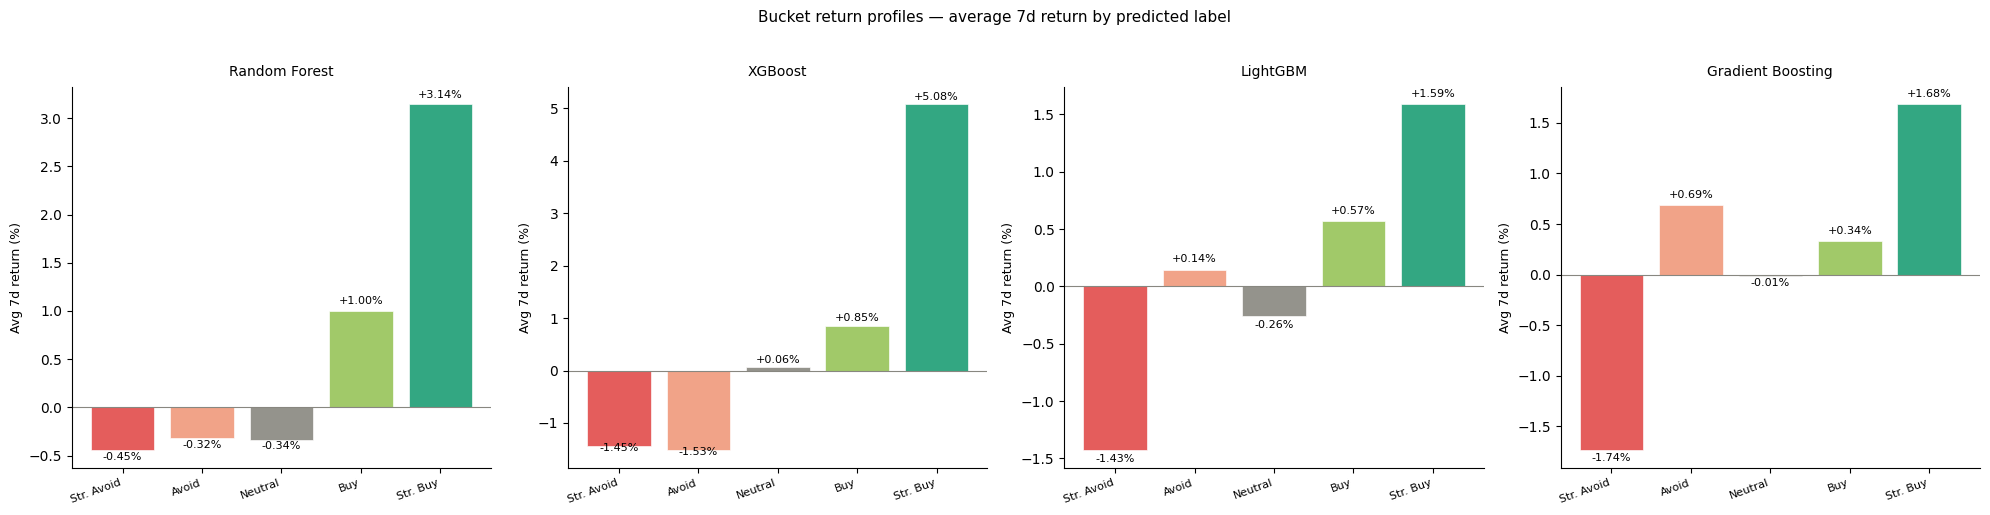

Saved -> fig2_bucket_returns.png


In [13]:
n_models = len(MODELS)
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 5), sharey=False)
fig.patch.set_facecolor('white')
bucket_colors = [COLORS[l] for l in LABEL_ORDER]

for ax, (name, y_pred) in zip(axes, predictions.items()):
    y_pred_labels = pd.Series([LABEL_ORDER[p] for p in y_pred], index=test_df.index)
    bdf = bucket_stats(y_pred_labels, test_df)
    bars = ax.bar(range(len(LABEL_ORDER)), bdf['avg'],
                  color=bucket_colors, edgecolor='white', linewidth=0.5, alpha=0.9)
    ax.axhline(0, color='#888780', lw=0.8)
    ax.set_xticks(range(len(LABEL_ORDER)))
    ax.set_xticklabels(
        ['Str. Avoid', 'Avoid', 'Neutral', 'Buy', 'Str. Buy'],
        fontsize=8, rotation=20, ha='right'
    )
    ax.set_title(name, fontsize=10, fontweight='500', pad=8)
    ax.set_ylabel('Avg 7d return (%)', fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_facecolor('white')
    for bar, val in zip(bars, bdf['avg']):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + (0.05 if val >= 0 else -0.12),
                f'{val:+.2f}%', ha='center', va='bottom', fontsize=8)

plt.suptitle('Bucket return profiles — average 7d return by predicted label',
             fontsize=11, fontweight='500', y=1.02)
plt.tight_layout()
path = OUT_DIR / 'fig2_bucket_returns.png'
plt.savefig(path, dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved -> {path.name}')

## 9. Figure 3 — Weekly spread and win rate comparison

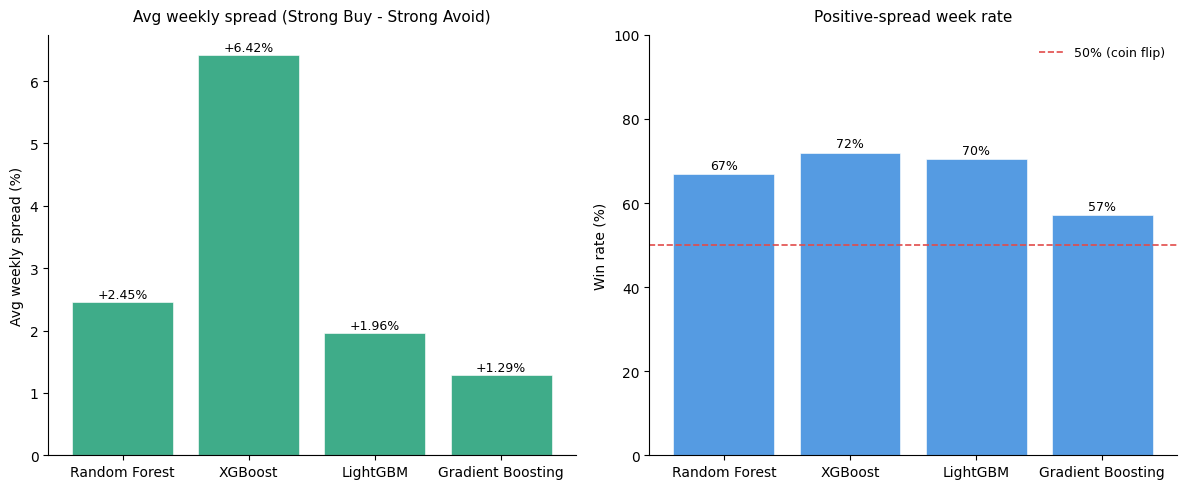

Saved -> fig3_strategy_comparison.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor('white')
x = range(len(model_names))

ax = axes[0]
bars = ax.bar(x, results_df['Avg Spread (%)'], color='#1D9E75', alpha=0.85,
              edgecolor='white', linewidth=0.5)
ax.axhline(0, color='#888780', lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=10)
ax.set_ylabel('Avg weekly spread (%)', fontsize=10)
ax.set_title('Avg weekly spread (Strong Buy - Strong Avoid)',
             fontsize=11, fontweight='500', pad=10)
ax.spines[['top', 'right']].set_visible(False)
ax.set_facecolor('white')
for bar, val in zip(bars, results_df['Avg Spread (%)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:+.2f}%', ha='center', va='bottom', fontsize=9)

ax = axes[1]
bars = ax.bar(x, results_df['Win Rate (%)'], color='#378ADD', alpha=0.85,
              edgecolor='white', linewidth=0.5)
ax.axhline(50, color='#E24B4A', lw=1.2, ls='--', label='50% (coin flip)')
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=10)
ax.set_ylabel('Win rate (%)', fontsize=10)
ax.set_title('Positive-spread week rate', fontsize=11, fontweight='500', pad=10)
ax.set_ylim(0, 100)
ax.legend(fontsize=9, framealpha=0)
ax.spines[['top', 'right']].set_visible(False)
ax.set_facecolor('white')
for bar, val in zip(bars, results_df['Win Rate (%)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.0f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
path = OUT_DIR / 'fig3_strategy_comparison.png'
plt.savefig(path, dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved -> {path.name}')

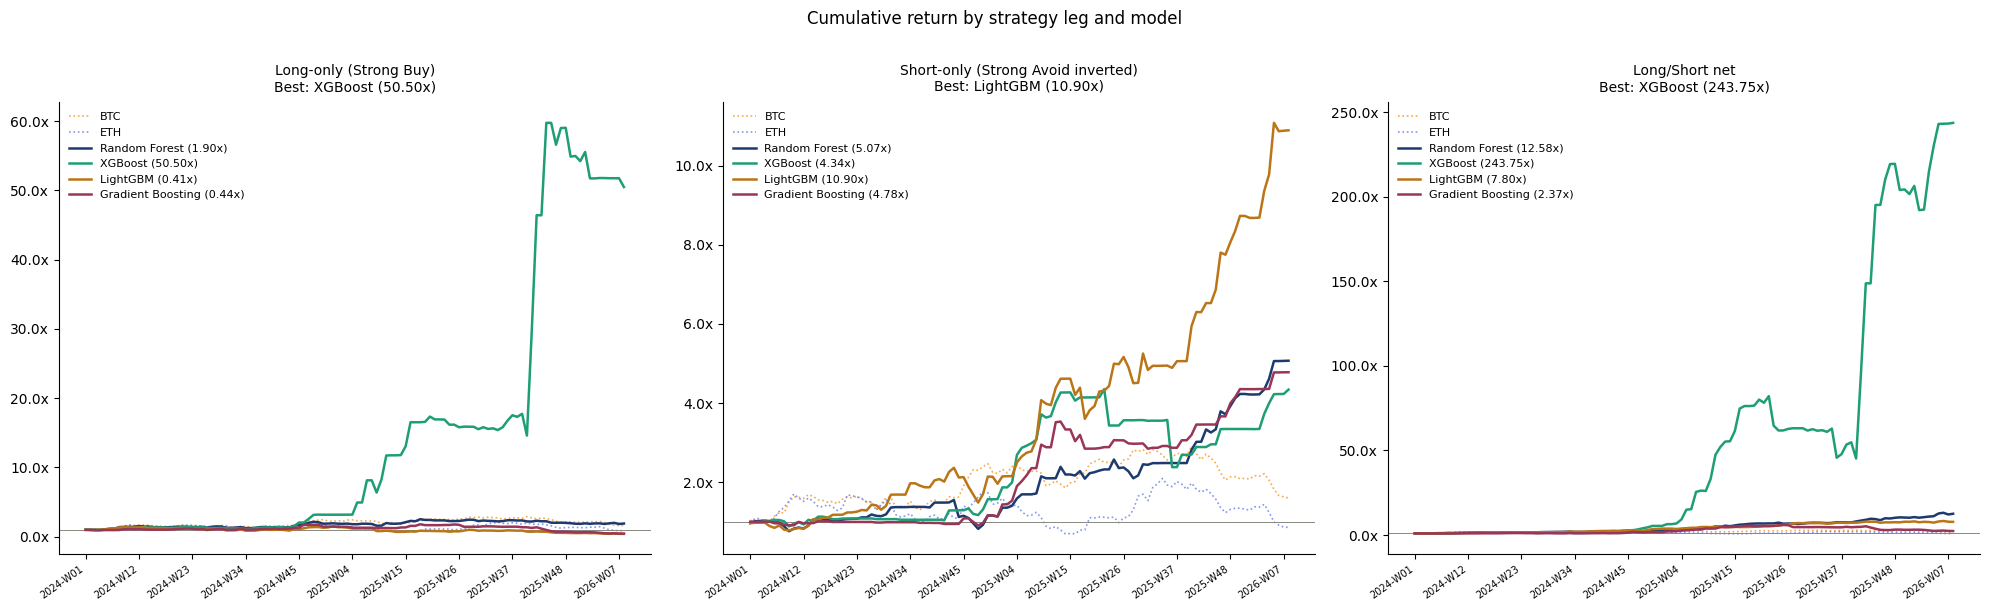

Saved -> fig4_cumulative_by_model.png

=== WINNER SUMMARY ===
Long-only (Strong Buy)              → Best: XGBoost  (50.50x)
   XGBoost                   50.50x
   Random Forest             1.90x
   Gradient Boosting         0.44x
   LightGBM                  0.41x
Short-only (Strong Avoid inverted)  → Best: LightGBM  (10.90x)
   LightGBM                  10.90x
   Random Forest             5.07x
   Gradient Boosting         4.78x
   XGBoost                   4.34x
Long/Short net                      → Best: XGBoost  (243.75x)
   XGBoost                   243.75x
   Random Forest             12.58x
   LightGBM                  7.80x
   Gradient Boosting         2.37x


In [ ]:
def cumret(s):
    return (1 + s.fillna(0)).cumprod()

def build_weekly_legs(y_pred_array, test_df):
    """
    For each week, compute:
      long_ret  = median fwd return of predicted Strong Buy coins
      short_ret = median fwd return of predicted Strong Avoid coins
    Returns a DataFrame indexed by week with long_ret, short_ret, net columns.
    """
    y_pred_labels = pd.Series(
        [LABEL_ORDER[p] for p in y_pred_array],
        index=test_df.index
    )
    rows = []
    for wk in sorted(test_df['year_week'].unique()):
        m = test_df[test_df['year_week'] == wk]
        lbl = y_pred_labels[m.index]
        long_r  = m[lbl == LONG_LABEL]['forward_return_7d'].median()
        short_r = m[lbl == SHORT_LABEL]['forward_return_7d'].median()
        rows.append({
            'week':      wk,
            'long_ret':  long_r  if pd.notna(long_r)  else 0.0,
            'short_ret': short_r if pd.notna(short_r) else 0.0,
        })
    df_out = pd.DataFrame(rows).set_index('week')
    df_out['short_pnl'] = -df_out['short_ret']   # profit from shorting
    df_out['net']       = df_out['long_ret'] - df_out['short_ret']
    return df_out

# BTC and ETH benchmarks
test_start = pd.Timestamp(TRAIN_CUTOFF + '-01')
btc_w = (df[df['asset_id'] == 'bitcoin']
         .set_index('date')['close']
         .resample('W').last()
         .pct_change()
         .loc[test_start:])
eth_w = (df[df['asset_id'] == 'ethereum']
         .set_index('date')['close']
         .resample('W').last()
         .pct_change()
         .loc[test_start:])

legs = {}
for name, y_pred in predictions.items():
    legs[name] = build_weekly_legs(y_pred, test_df)

n_weeks = min(len(v) for v in legs.values())

MODEL_COLORS = {
    'Random Forest':     '#1D3A6E',
    'XGBoost':           '#1D9E75',
    'LightGBM':          '#BA7517',
    'Gradient Boosting': '#993556',
}
LINE_STYLES = {
    'long_ret':  '-',
    'short_pnl': '--',
    'net':       '-',
}

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=False)
fig.patch.set_facecolor('white')
titles = ['Long-only (Strong Buy)', 'Short-only (Strong Avoid inverted)', 'Long/Short net']
legs_keys = ['long_ret', 'short_pnl', 'net']

for ax, leg_key, title in zip(axes, legs_keys, titles):
    btc_cum = cumret(btc_w.reset_index(drop=True).iloc[:n_weeks])
    eth_cum = cumret(eth_w.reset_index(drop=True).iloc[:n_weeks])
    ax.plot(range(n_weeks), btc_cum.values, color='#F7931A',
            lw=1.2, ls=':', alpha=0.8, label='BTC')
    ax.plot(range(n_weeks), eth_cum.values, color='#627EEA',
            lw=1.2, ls=':', alpha=0.8, label='ETH')
    ax.axhline(1.0, color='#888780', lw=0.7, ls='-')
    best_final = {}
    for name, df_legs in legs.items():
        series = df_legs[leg_key].iloc[:n_weeks]
        cum    = cumret(series).values
        ax.plot(range(n_weeks), cum,
                color=MODEL_COLORS[name], lw=1.8,
                label=f'{name} ({cum[-1]:.2f}x)')
        best_final[name] = cum[-1]
    best_name = max(best_final, key=best_final.get)
    ax.set_title(f'{title}\nBest: {best_name} ({best_final[best_name]:.2f}x)',
                 fontsize=10, fontweight='500', pad=8)
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'{v:.1f}x'))
    wk_labels = sorted(test_df['year_week'].unique())[:n_weeks]
    step = max(1, n_weeks // 10)
    ax.set_xticks(range(0, n_weeks, step))
    ax.set_xticklabels(wk_labels[::step], rotation=35, ha='right', fontsize=7)

    ax.legend(fontsize=8, framealpha=0, loc='upper left')
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_facecolor('white')

plt.suptitle('Cumulative return by strategy leg and model',
             fontsize=12, fontweight='500', y=1.01)
plt.tight_layout()
path = OUT_DIR / 'fig4_cumulative_by_model.png'
plt.savefig(path, dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved -> {path.name}')

print('\n=== WINNER SUMMARY ===')
for leg_key, title in zip(legs_keys, titles):
    scores = {name: cumret(legs[name][leg_key].iloc[:n_weeks]).values[-1]
              for name in legs}
    winner = max(scores, key=scores.get)
    print(f'{title:<35} → Best: {winner}  ({scores[winner]:.2f}x)')
    for name, val in sorted(scores.items(), key=lambda x: -x[1]):
        print(f'   {name:<25} {val:.2f}x')

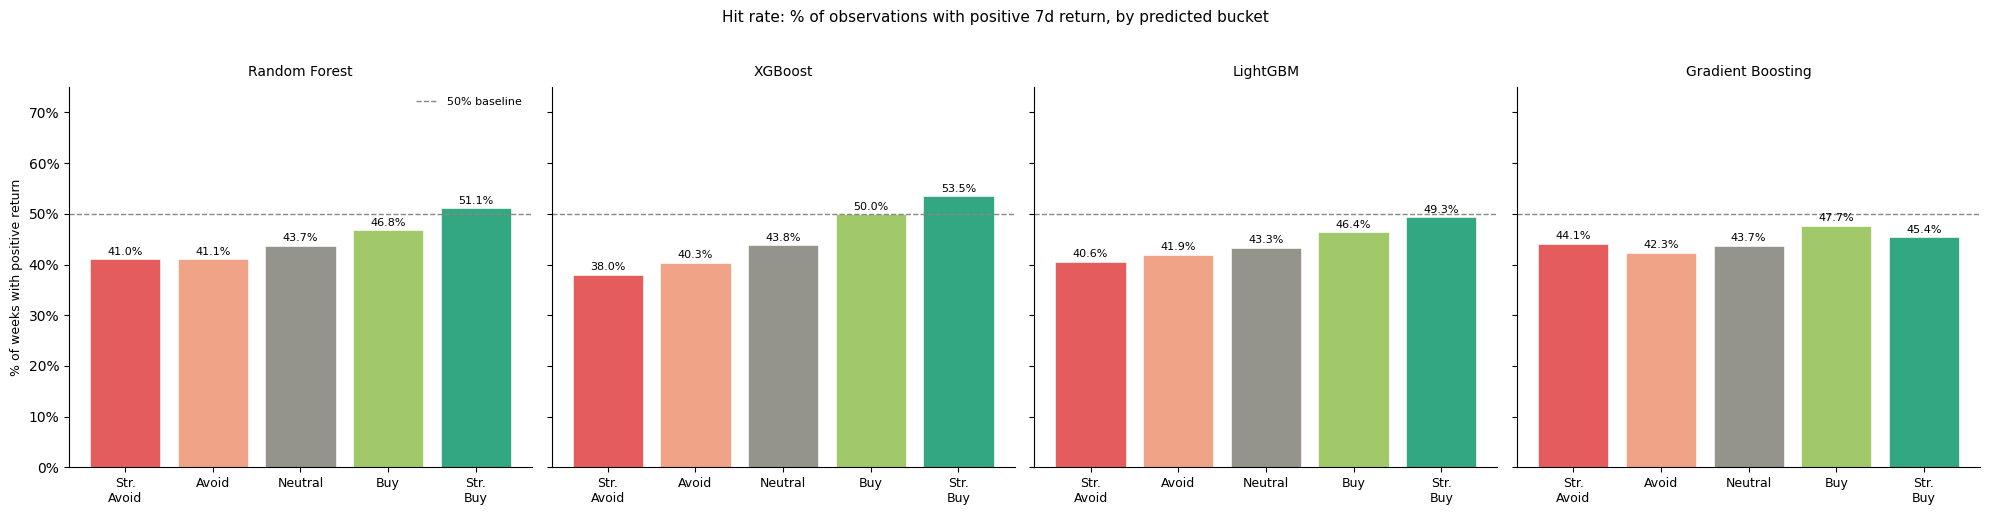

Saved -> fig5_hit_rate_by_model.png

=== HIT RATE TABLE (% of weeks positive) ===
              Random Forest  XGBoost  LightGBM  Gradient Boosting
label                                                            
Strong Avoid           41.0     38.0      40.6               44.1
Avoid                  41.1     40.3      41.9               42.3
Neutral                43.7     43.8      43.3               43.7
Buy                    46.8     50.0      46.4               47.7
Strong Buy             51.1     53.5      49.3               45.4

=== MONOTONICITY CHECK ===
Random Forest             monotonic: True  |  spread: +10.1pp  (Strong Buy 51.1% vs Strong Avoid 41.0%)
XGBoost                   monotonic: True  |  spread: +15.4pp  (Strong Buy 53.5% vs Strong Avoid 38.0%)
LightGBM                  monotonic: True  |  spread: +8.7pp  (Strong Buy 49.3% vs Strong Avoid 40.6%)
Gradient Boosting         monotonic: False  |  spread: +1.3pp  (Strong Buy 45.4% vs Strong Avoid 44.1%)


In [ ]:
def hit_rate_by_bucket(y_pred_array, test_df):
    """
    For each predicted label, compute the % of individual asset-week
    observations where the 7d forward return was positive.
    """
    y_pred_labels = pd.Series(
        [LABEL_ORDER[p] for p in y_pred_array],
        index=test_df.index
    )
    rows = []
    for label in LABEL_ORDER:
        mask = y_pred_labels == label
        ret  = test_df.loc[mask, 'forward_return_7d']
        rows.append({
            'label':    label,
            'hit_rate': (ret > 0).mean() * 100,
            'n':        len(ret),
        })
    return pd.DataFrame(rows)

hit_dfs = {}
for name, y_pred in predictions.items():
    hit_dfs[name] = hit_rate_by_bucket(y_pred, test_df)

n_models  = len(predictions)
bar_colors = [COLORS[l] for l in LABEL_ORDER]
x = range(len(LABEL_ORDER))

fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 5), sharey=True)
fig.patch.set_facecolor('white')

for ax, (name, hdf) in zip(axes, hit_dfs.items()):
    bars = ax.bar(x, hdf['hit_rate'],
                  color=bar_colors, edgecolor='white',
                  linewidth=0.5, alpha=0.9)
    ax.axhline(50, color='#888780', lw=1.0, ls='--', label='50% baseline')
    ax.set_xticks(x)
    ax.set_xticklabels(
        ['Str.\nAvoid', 'Avoid', 'Neutral', 'Buy', 'Str.\nBuy'],
        fontsize=9
    )
    ax.set_ylim(0, 75)
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'{v:.0f}%'))
    ax.set_title(name, fontsize=10, fontweight='500', pad=8)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_facecolor('white')
    if ax == axes[0]:
        ax.set_ylabel('% of weeks with positive return', fontsize=9)
        ax.legend(fontsize=8, framealpha=0)
    # Value labels on bars
    for bar, val in zip(bars, hdf['hit_rate']):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.5,
                f'{val:.1f}%',
                ha='center', va='bottom', fontsize=8)

plt.suptitle('Hit rate: % of observations with positive 7d return, by predicted bucket',
             fontsize=11, fontweight='500', y=1.02)
plt.tight_layout()
path = OUT_DIR / 'fig5_hit_rate_by_model.png'
plt.savefig(path, dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved -> {path.name}')

# ── Print hit rate table for all models ──────────────────────────────────────
print('\n=== HIT RATE TABLE (% of weeks positive) ===')
summary = pd.DataFrame({name: hdf.set_index('label')['hit_rate']
                         for name, hdf in hit_dfs.items()})
print(summary.round(1).to_string())

# ── Monotonicity check ───────────────────────────────────────────────────────
print('\n=== MONOTONICITY CHECK ===')
for name, hdf in hit_dfs.items():
    rates = hdf['hit_rate'].tolist()
    is_mono = all(rates[i] <= rates[i+1] for i in range(len(rates)-1))
    print(f'{name:<25} monotonic: {is_mono}  |  '
          f'spread: {rates[-1] - rates[0]:+.1f}pp  '
          f'(Strong Buy {rates[-1]:.1f}% vs Strong Avoid {rates[0]:.1f}%)')

## 10. Save best model

In [17]:
best_name = results_df.loc[results_df['Avg Spread (%)'].idxmax(), 'Model']
best_clf  = trained_models[best_name]

with open(BEST_MODEL, 'wb') as f:
    pickle.dump(best_clf, f)

print(f'Best model by avg spread: {best_name}')
print(f'Saved -> {BEST_MODEL.name}')
print(f'\nFull results -> {RESULTS_FILE.name}')
print(f'Figures      -> {OUT_DIR.name}/')

print('\n=== FINAL TABLE ===')
print(results_df.to_string(index=False))

Best model by avg spread: XGBoost
Saved -> model_comparison_best.pkl

Full results -> model_comparison_results.csv
Figures      -> model_comparison_figures/

=== FINAL TABLE ===
            Model  Accuracy (%)  Macro F1 (%)  Lift (pp)  Avg Spread (%)  Win Rate (%)  Ann. Spread (%)
    Random Forest         34.49         24.66      14.49            2.45          67.0            127.3
          XGBoost         38.17         18.84      18.17            6.42          72.0            333.9
         LightGBM         29.14         23.24       9.14            1.96          70.5            101.7
Gradient Boosting         36.39         19.73      16.39            1.29          57.1             67.0


In [ ]:
xgb_pred = pd.Series([LABEL_ORDER[p] for p in predictions['XGBoost']], index=test_df.index)
sb_per_week = test_df[xgb_pred == 'Strong Buy'].groupby('year_week').size()
print(sb_per_week.describe())
print(f'\nWeeks with 0 Strong Buy coins: {(sb_per_week == 0).sum()}')
print(f'Weeks with 1-3 coins: {((sb_per_week >= 1) & (sb_per_week <= 3)).sum()}')

xgb_legs = build_weekly_legs(predictions['XGBoost'], test_df)
print('\nTop 10 best weeks by net P&L:')
print(xgb_legs['net'].nlargest(10))